<a href="https://colab.research.google.com/github/vishnupriyauppada-crypto/Cinetech.VS/blob/main/Cinetech_vs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        MOVIE RECOMMENDER MINI-SYSTEM USING SVD

There are 5 users and 8 movies.
Give a rating from 1 to 5.
Enter 0 if you have NOT rated that movie yet.


----------------------------------------------------------------------
ENTER DETAILS FOR USER 1
----------------------------------------------------------------------
Enter name of User 1: Saranya

Saranya, enter your ratings:
  Inception: 0
  Titanic: 3
  Avengers: 4
  Toy Story: 2
  Joker: 2
  Salaar: 4
  Sita Ramam: 5
  RRR: 5

----------------------------------------------------------------------
ENTER DETAILS FOR USER 2
----------------------------------------------------------------------
Enter name of User 2: Vishnu

Vishnu, enter your ratings:
  Inception: 3
  Titanic: 4
  Avengers: 3
  Toy Story: 2
  Joker: 0
  Salaar: 4
  Sita Ramam: 5
  RRR: 5

----------------------------------------------------------------------
ENTER DETAILS FOR USER 3
----------------------------------------------------------------------
Enter name of

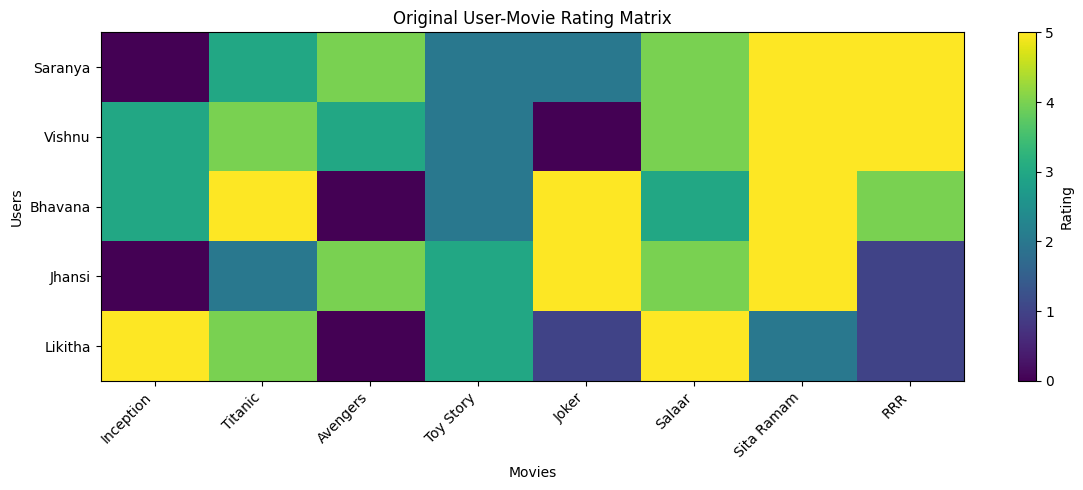

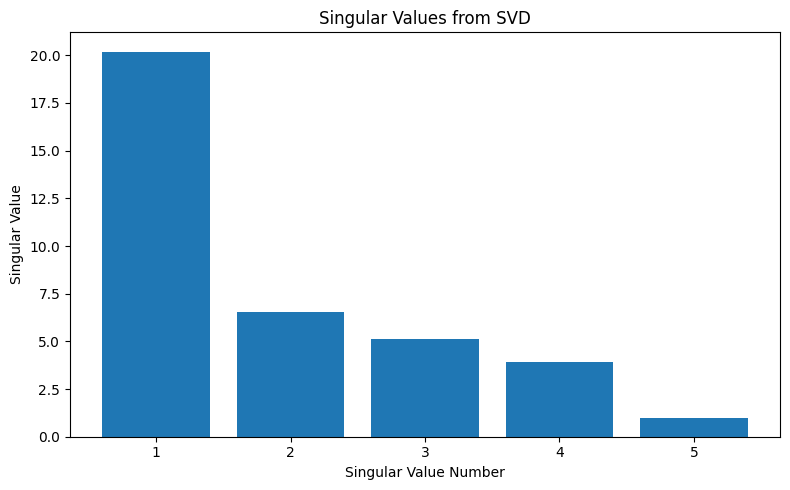

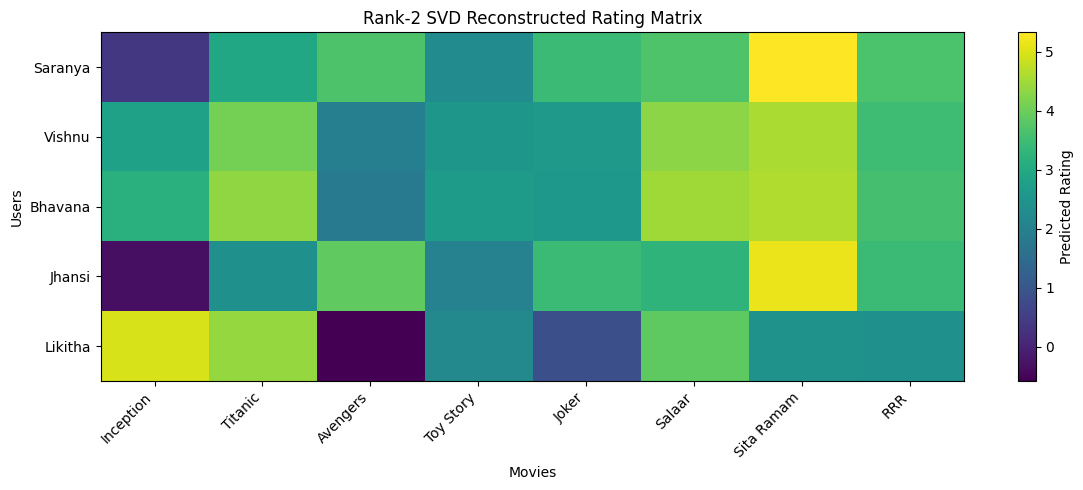

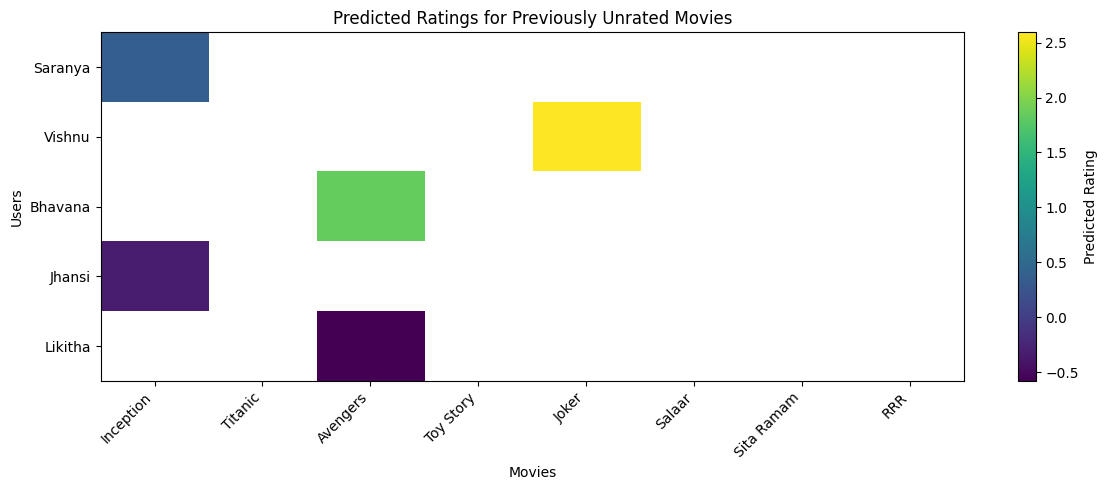


                   MATHEMATICAL SUMMARY

Rating Matrix:
    R = User-Movie rating matrix

SVD:
    R = U × Σ × Vᵀ

Top-2 approximation:
    R̂ = U₂ × Σ₂ × V₂ᵀ

Missing rating prediction:
    Predicted rating = corresponding value in R̂

Recommendation:
    Select the unrated movie having the highest
    predicted rating.

Project configuration:
    5 Users
    8 Movies
    Top 2 Singular Values

Movies:
    1. Inception
    2. Titanic
    3. Avengers
    4. Toy Story
    5. Joker
    6. Salaar
    7. Sita Ramam
    8. RRR

Important assumption:
    0 means "not rated", NOT a real rating of zero.

              MOVIE RECOMMENDER SYSTEM COMPLETE


In [ ]:
# ================================================================
# MOVIE RECOMMENDER MINI-SYSTEM USING SVD
# 5 Users | 8 Movies | Top-2 Singular Values
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------
# 1. PROJECT SETTINGS
# ------------------------------------------------

NUM_USERS = 5
NUM_MOVIES = 8
TOP_K = 2

# 8 movies for the project
MOVIES = [
    "Inception",
    "Titanic",
    "Avengers",
    "Toy Story",
    "Joker",
    "Salaar",
    "Sita Ramam",
    "RRR"
]

print("=" * 70)
print("        MOVIE RECOMMENDER MINI-SYSTEM USING SVD")
print("=" * 70)

print("\nThere are 5 users and 8 movies.")
print("Give a rating from 1 to 5.")
print("Enter 0 if you have NOT rated that movie yet.\n")


# ------------------------------------------------
# 2. TAKE USER INPUT
# ------------------------------------------------

USERS = []
ratings_list = []

for i in range(NUM_USERS):

    print("\n" + "-" * 70)
    print(f"ENTER DETAILS FOR USER {i + 1}")
    print("-" * 70)

    # Ask user's name
    while True:

        name = input(f"Enter name of User {i + 1}: ").strip()

        if name == "":
            print("Name cannot be empty. Please enter a name.")

        elif name in USERS:
            print("This name is already used. Please enter another name.")

        else:
            break

    USERS.append(name)

    # Store ratings
    user_ratings = []

    print(f"\n{name}, enter your ratings:")

    for movie in MOVIES:

        while True:

            try:

                rating = float(
                    input(f"  {movie}: ")
                )

                # Check rating range
                if rating < 0 or rating > 5:
                    print("Please enter a rating between 0 and 5.")
                    continue

                # Only whole-number ratings
                if rating != int(rating):
                    print(
                        "Please enter a whole number: "
                        "0, 1, 2, 3, 4 or 5."
                    )
                    continue

                rating = int(rating)

                user_ratings.append(rating)

                break

            except ValueError:

                print(
                    "Invalid input. Please enter "
                    "0, 1, 2, 3, 4 or 5."
                )

    ratings_list.append(user_ratings)


# ------------------------------------------------
# 3. CREATE RATING MATRIX
# ------------------------------------------------

R = np.array(
    ratings_list,
    dtype=float
)

print("\n\n" + "=" * 70)
print("                 ORIGINAL RATING MATRIX")
print("=" * 70)

rating_df = pd.DataFrame(
    R.astype(int),
    index=USERS,
    columns=MOVIES
)

print(rating_df)

print("\n0 = Movie has NOT been rated")


# ------------------------------------------------
# 4. CHECK FOR MISSING RATINGS
# ------------------------------------------------

if np.all(R != 0):

    print("\nWARNING:")
    print("No missing ratings were entered.")
    print("Enter 0 for movies that a user has not rated.")

else:

    print("\nMissing ratings detected successfully.")


# ------------------------------------------------
# 5. SINGULAR VALUE DECOMPOSITION
# ------------------------------------------------

print("\n" + "=" * 70)
print("             STEP 1: SINGULAR VALUE DECOMPOSITION")
print("=" * 70)

print("\nMathematical model:")
print("R = U × Σ × Vᵀ")

# Calculate SVD
U, singular_values, Vt = np.linalg.svd(
    R,
    full_matrices=False
)

print("\nU matrix:")
print(np.round(U, 4))

print("\nSingular values:")
print(np.round(singular_values, 4))

print("\nVᵀ matrix:")
print(np.round(Vt, 4))


# ------------------------------------------------
# 6. KEEP TOP-2 SINGULAR VALUES
# ------------------------------------------------

print("\n" + "=" * 70)
print("             STEP 2: TOP-2 SINGULAR VALUES")
print("=" * 70)

U_2 = U[:, :TOP_K]

Sigma_2 = np.diag(
    singular_values[:TOP_K]
)

Vt_2 = Vt[:TOP_K, :]

print("\nTop-2 singular values:")
print(
    np.round(
        singular_values[:TOP_K],
        4
    )
)

print("\nU₂:")
print(np.round(U_2, 4))

print("\nΣ₂:")
print(np.round(Sigma_2, 4))

print("\nV₂ᵀ:")
print(np.round(Vt_2, 4))


# ------------------------------------------------
# 7. RANK-2 LOW-RANK APPROXIMATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("             STEP 3: RANK-2 APPROXIMATION")
print("=" * 70)

# R̂ = U₂ × Σ₂ × V₂ᵀ
R_hat = U_2 @ Sigma_2 @ Vt_2

print("\nPredicted rating matrix:")
print(np.round(R_hat, 2))

prediction_df = pd.DataFrame(
    np.round(R_hat, 2),
    index=USERS,
    columns=MOVIES
)

print("\nReadable predicted-rating table:")
print(prediction_df)


# ------------------------------------------------
# 8. PREDICT ONLY MISSING RATINGS
# ------------------------------------------------

print("\n" + "=" * 70)
print("             STEP 4: PREDICT MISSING RATINGS")
print("=" * 70)

# Start with NaN everywhere
missing_predictions = np.full_like(
    R_hat,
    np.nan
)

for i in range(NUM_USERS):

    for j in range(NUM_MOVIES):

        # 0 means the movie was not rated
        if R[i, j] == 0:

            missing_predictions[i, j] = R_hat[i, j]


missing_df = pd.DataFrame(
    np.round(missing_predictions, 2),
    index=USERS,
    columns=MOVIES
)

print(
    "\nPredicted ratings for previously "
    "unrated movies:"
)

print(missing_df)


# ------------------------------------------------
# 9. RECOMMENDATION ENGINE
# ------------------------------------------------

print("\n" + "=" * 70)
print("                 STEP 5: RECOMMENDATIONS")
print("=" * 70)

recommendations = []

for i in range(NUM_USERS):

    # Find movies with rating 0
    unrated_indices = np.where(
        R[i] == 0
    )[0]

    if len(unrated_indices) == 0:

        recommendations.append(
            [
                USERS[i],
                "No recommendation",
                "-"
            ]
        )

        print(f"\n{USERS[i]}:")
        print(
            "  All movies have already been rated."
        )

    else:

        # Get predicted ratings
        predicted_values = R_hat[
            i,
            unrated_indices
        ]

        # Find maximum predicted rating
        best_position = np.argmax(
            predicted_values
        )

        best_movie_index = (
            unrated_indices[best_position]
        )

        best_movie = MOVIES[
            best_movie_index
        ]

        best_rating = R_hat[
            i,
            best_movie_index
        ]

        recommendations.append(
            [
                USERS[i],
                best_movie,
                round(best_rating, 2)
            ]
        )

        print(f"\n{USERS[i]}:")
        print(
            f"  Recommended Movie : {best_movie}"
        )

        print(
            f"  Predicted Rating  : "
            f"{best_rating:.2f} / 5"
        )


# ------------------------------------------------
# 10. FINAL RECOMMENDATION TABLE
# ------------------------------------------------

print("\n" + "=" * 70)
print("                  FINAL RECOMMENDATION TABLE")
print("=" * 70)

recommendation_df = pd.DataFrame(
    recommendations,
    columns=[
        "User",
        "Recommended Movie",
        "Predicted Rating"
    ]
)

print(
    recommendation_df.to_string(
        index=False
    )
)


# ------------------------------------------------
# 11. SHOW ALL RECOMMENDATION CANDIDATES
# ------------------------------------------------

print("\n" + "=" * 70)
print("             PREDICTED RATINGS FOR UNRATED MOVIES")
print("=" * 70)

for i in range(NUM_USERS):

    unrated_indices = np.where(
        R[i] == 0
    )[0]

    print(f"\n{USERS[i]}:")

    if len(unrated_indices) == 0:

        print("  No unrated movies.")

    else:

        candidates = []

        for j in unrated_indices:

            candidates.append(
                (
                    MOVIES[j],
                    R_hat[i, j]
                )
            )

        # Highest predicted rating first
        candidates.sort(
            key=lambda x: x[1],
            reverse=True
        )

        for movie, predicted_rating in candidates:

            print(
                f"  {movie:<15} → "
                f"Predicted Rating = "
                f"{predicted_rating:.2f}"
            )


# ------------------------------------------------
# 12. VISUALIZATION 1
# ORIGINAL RATING MATRIX
# ------------------------------------------------

plt.figure(figsize=(12, 5))

plt.imshow(
    R,
    aspect="auto"
)

plt.colorbar(
    label="Rating"
)

plt.xticks(
    range(NUM_MOVIES),
    MOVIES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_USERS),
    USERS
)

plt.title(
    "Original User-Movie Rating Matrix"
)

plt.xlabel("Movies")
plt.ylabel("Users")

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 13. VISUALIZATION 2
# SINGULAR VALUES
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    range(1, len(singular_values) + 1),
    singular_values
)

plt.xlabel(
    "Singular Value Number"
)

plt.ylabel(
    "Singular Value"
)

plt.title(
    "Singular Values from SVD"
)

plt.xticks(
    range(
        1,
        len(singular_values) + 1
    )
)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 14. VISUALIZATION 3
# RANK-2 PREDICTED MATRIX
# ------------------------------------------------

plt.figure(figsize=(12, 5))

plt.imshow(
    R_hat,
    aspect="auto"
)

plt.colorbar(
    label="Predicted Rating"
)

plt.xticks(
    range(NUM_MOVIES),
    MOVIES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_USERS),
    USERS
)

plt.title(
    "Rank-2 SVD Reconstructed Rating Matrix"
)

plt.xlabel("Movies")
plt.ylabel("Users")

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 15. VISUALIZATION 4
# MISSING-RATING PREDICTIONS
# ------------------------------------------------

plt.figure(figsize=(12, 5))

plt.imshow(
    np.ma.masked_invalid(
        missing_predictions
    ),
    aspect="auto"
)

plt.colorbar(
    label="Predicted Rating"
)

plt.xticks(
    range(NUM_MOVIES),
    MOVIES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_USERS),
    USERS
)

plt.title(
    "Predicted Ratings for Previously Unrated Movies"
)

plt.xlabel("Movies")
plt.ylabel("Users")

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 16. MATHEMATICAL SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("                   MATHEMATICAL SUMMARY")
print("=" * 70)

print("""
Rating Matrix:
    R = User-Movie rating matrix

SVD:
    R = U × Σ × Vᵀ

Top-2 approximation:
    R̂ = U₂ × Σ₂ × V₂ᵀ

Missing rating prediction:
    Predicted rating = corresponding value in R̂

Recommendation:
    Select the unrated movie having the highest
    predicted rating.

Project configuration:
    5 Users
    8 Movies
    Top 2 Singular Values

Movies:
    1. Inception
    2. Titanic
    3. Avengers
    4. Toy Story
    5. Joker
    6. Salaar
    7. Sita Ramam
    8. RRR

Important assumption:
    0 means "not rated", NOT a real rating of zero.
""")

print("=" * 70)
print("              MOVIE RECOMMENDER SYSTEM COMPLETE")
print("=" * 70)